In [2]:
import numpy as np 
from scipy.integrate import odeint 
import matplotlib.pyplot as plt

In [1]:
# starting with simple model and going to progress one tracer or flux one by one adding to the vector
# this will be in concentrations
# GoC volume is 145,000 km3. 1.45e16 m3 = 1.48e19 kg (converted with seawater)

In [ ]:
# questions
# Do I need a different 'model' for every tracer?
# mass = concentration * volume --> concentration = mass (tracer) / volume 

In [ ]:
# dependent variable(s) = carbon 
# independent variable(s) = time
# physical processe(s) = flow in, flow out
# boundaries of model = carbon can only enter and exit through 1 location. carbon cannot be produced inside the reservoir
# physical laws = conservation of mass, ficks law?
# assumptions = 

# Balance
# time rate of change of carbon in the gulf = the rate at which it enters the gulf - the rate at which it exits the gulf
# dy/dt = y*vol - y*vol 
# units (mol/kg) = mass * vol - mass * vol

# inital conditions: moles carbon inside = 500
# boundary conditions: moles carbon outside = 1000, only enters exits same spot

In [ ]:
# Moce Matm with units of gigatons (same as a petagram)

Time rate change of mass = mass rate in - mass rate out + source/sink
- ignoring sources and sinks of carbon within the model for now

One box with arbitary fluxes

Text(0, 0.5, 'y(t)')

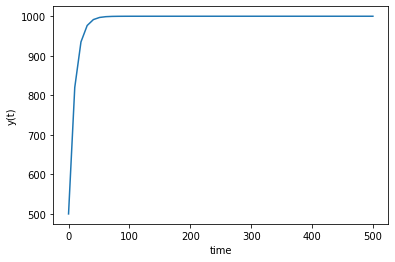

In [15]:
boxvol = [1.45e5] # units km^3
def model(y,t):
    # Fin - Fout
    #dydt = () * boxvol
    dydt = 100-0.1*y
    return dydt

# intial condition (can be a vector as well)
y0 = [500,200]
# time points
t = np.linspace(0,500)
# solve ode
y = odeint(model,y0,t)

# plot results
plt.plot(t,y[0])
plt.xlabel('time')
plt.ylabel('y(t)')

two boxes (surface and deep) and one tracer

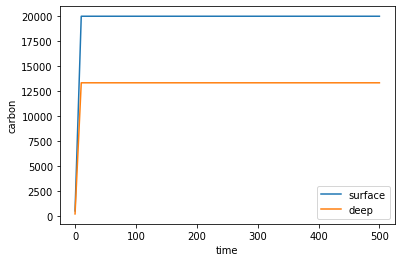

In [28]:
def model(y,t):
    # Fin - Fout
    # parameters are abitrary
    F_DS = y[1]*3 
    F_SNP = y[0]*2
    F_NPD = 40000*1 
    dy1 = F_DS - F_SNP
    dy2 = F_NPD - F_DS
    return dy1,dy2

# intial condition 
# surface, deep
y0 = [500,200]
# time points
t = np.linspace(0,500)
# solve ode
y = odeint(model,y0,t)

# plot results
plt.plot(t,y[:,0],label= 'surface')
plt.plot(t,y[:,1],label='deep')
plt.xlabel('time')
plt.ylabel('carbon')
plt.legend(loc='best')

two boxes and two tracers 

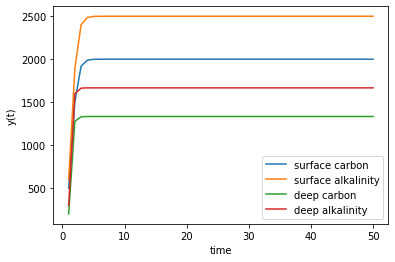

In [38]:
def model(y,t):
    # Fin - Fout
    # equations and parameters are abitrary
    F_DS = [y[2]*3,y[3]*3]
    F_SNP = [y[0]*2,y[1]*2]
    F_NPD = [4000*1,5000*1]
    dSC = F_DS[0] - F_SNP[0]
    dSA = F_DS[1] - F_SNP[1]
    dDC = F_NPD[0] - F_DS[0]
    dDA = F_NPD[1] - F_DS[1]
    return dSC,dSA,dDC,dDA

# intial condition 
# surface (all tracers), deep (all tracers)
# carbon, ALK
y0 = [500,600,200,300]
# time points
t = np.linspace(1,50,50)
# solve ode
y = odeint(model,y0,t)

# plot results
plt.plot(t,y[:,0],label= 'surface carbon')
plt.plot(t,y[:,1],label='surface alkalinity')
plt.plot(t,y[:,2],label= 'deep carbon')
plt.plot(t,y[:,3],label='deep alkalinity')

plt.xlabel('time')
plt.ylabel('y(t)')
plt.legend(loc='best')

3 boxes (surface, intermediate, and deep) and 4 tracers with circulation vector

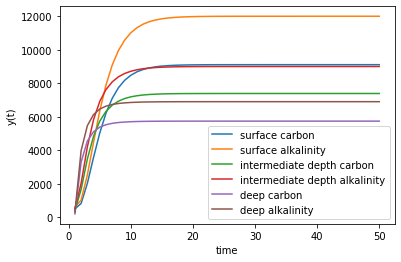

In [78]:
def model(y,t):
    # equations and parameters are currently arbitrary 
    
    # circulation vector (matrix?)
    # BC surf int deep BC
    # Soce Satm Sint intS intD Dint Doce
    circ = [0.6,0.05,0.1,0.8,0.1,1.0]
    
    # to adjust ocean circulation for deglacial
    if t > 17500:
        circulation = 0 # Glacial
    if 17500>t>14500 or 13000<t<11500:
        circulation = 0 # HS
    else:
        circulation = 0 # NADW
    # key: carbon is 0,2,4/alkalinity is 1,3,5
    
    # fluxes
    surf2oce = [y[0]*circ[0], y[1]*circ[0]] # outflow
    surf2atm = [y[0]*circ[1], 0] # gasexchange
    atm2surf = [10, 0] # gasexchange
    surf2int = [y[0]*circ[2], y[1]*circ[2]] # downwelling
    int2surf = [y[2]*circ[3], y[3]*circ[3]] # upwelling
    int2deep = [y[2]*circ[4], y[3]*circ[4]] # downwelling 
    deep2int = [y[4]*circ[5], y[5]*circ[5]] # upwelling
    oce2deep = [5000,6000] # inflow
    
    # reservoirs
    surfC = (atm2surf[0] + int2surf[0]) - (surf2oce[0] + surf2atm[0])
    surfA = (atm2surf[1] + int2surf[1]) - (surf2oce[1] + surf2atm[1])
    intC = (surf2int[0] + deep2int[0]) - (int2surf[0] + int2deep[0])
    intA = (surf2int[1] + deep2int[1]) - (int2surf[1] + int2deep[1])
    deepC = (oce2deep[0] + int2deep[0]) - deep2int[0]
    deepA = (oce2deep[1] + int2deep[1]) - deep2int[1]
    
    return surfC,surfA,intC,intA,deepC,deepA

# intial condition 
# surface (all tracers), deep (all tracers)
# carbon, ALK
y0 = [500,600,400,500,200,300]
# time points
t = np.linspace(1,50,50)
# solve ode
y = odeint(model,y0,t)

# plot results
plt.plot(t,y[:,0],label= 'surface carbon')
plt.plot(t,y[:,1],label='surface alkalinity')
plt.plot(t,y[:,2],label= 'intermediate depth carbon')
plt.plot(t,y[:,3],label='intermediate depth alkalinity')
plt.plot(t,y[:,4],label= 'deep carbon')
plt.plot(t,y[:,5],label='deep alkalinity')

plt.xlabel('time')
plt.ylabel('y(t)')
plt.legend(loc='best')

In [ ]:
# can have different circulations with different advective schemes 

3 boxes (surface, intermediate, and deep) and 4 tracers (C,ALK,d13C,d14C) with circulation vector

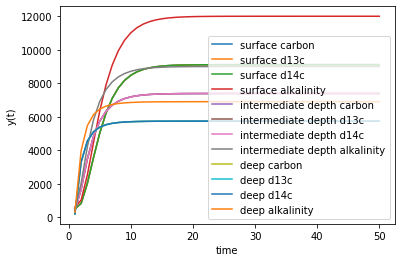

In [85]:
def model(y,t):
    # equations and parameters are currently arbitrary 

    # CIRCULATION
    # key: 
    # Soce Satm Sint intS intD Dint
    circ = [0.6,0.05,0.1,0.8,0.1,1.0]

    # to adjust ocean circulation for deglacial
    if t > 17500:
        circulation = 0 # Glacial
    if 17500>t>14500 or 13000<t<11500:
        circulation = 0 # HS
    else:
        circulation = 0 # NADW


    # FLUXES
    # key:
    # C: 0,4,8 d13c: 1,5,9 d14c: 2,6,10 ALK: 3,7,11
    # from atm
    atm2surf = [10, 10, 10, 0] # gasexchange

    # from surface
    surf2oce = [y[0]*circ[0], y[1]*circ[0], y[2]*circ[0], y[3]*circ[0]] # outflow
    surf2atm = [y[0]*circ[1], y[1]*circ[1], y[2]*circ[1], 0*circ[1]] # gasexchange
    surf2int = [y[0]*circ[2], y[1]*circ[2], y[2]*circ[2], y[3]*circ[2]] # downwelling

    # from intermediate depth
    int2surf = [y[4]*circ[3], y[5]*circ[3], y[6]*circ[3], y[7]*circ[3]] # upwelling
    int2deep = [y[4]*circ[4], y[5]*circ[4], y[6]*circ[4], y[7]*circ[4]] # downwelling 

    # from deep
    deep2int = [y[8]*circ[5], y[9]*circ[5], y[10]*circ[5], y[11]*circ[5]] # upwelling

    # from North Pacific
    oce2deep = [5000,5000,5000,6000] # inflow

    # RESERVOIRS

    #surface box
    surfC = (atm2surf[0] + int2surf[0]) - (surf2oce[0] + surf2atm[0])
    surfd13c = (atm2surf[1] + int2surf[1]) - (surf2oce[1] + surf2atm[1])
    surfd14c = (atm2surf[2] + int2surf[2]) - (surf2oce[2] + surf2atm[2])
    surfA = (atm2surf[3] + int2surf[3]) - (surf2oce[3] + surf2atm[3])

    # intermediate box
    intC = (surf2int[0] + deep2int[0]) - (int2surf[0] + int2deep[0])
    intd13c = (surf2int[1] + deep2int[1]) - (int2surf[1] + int2deep[1])
    intd14c = (surf2int[2] + deep2int[2]) - (int2surf[2] + int2deep[2])
    intA = (surf2int[3] + deep2int[3]) - (int2surf[3] + int2deep[3])

    # deep box
    deepC = (oce2deep[0] + int2deep[0]) - deep2int[0]
    deepd13c = (oce2deep[1] + int2deep[1]) - deep2int[1]
    deepd14c = (oce2deep[2] + int2deep[2]) - deep2int[2]
    deepA = (oce2deep[3] + int2deep[3]) - deep2int[3]

    return surfC,surfd13c,surfd14c,surfA,intC,intd13c,intd13c,intA,deepC,deepd13c,deepd14c,deepA

# intial condition 
# surface (all tracers), deep (all tracers)
# carbon, ALK
y0 = [500,500,500,600,400,400,400,500,200,200,200,300]
# time points
t = np.linspace(1,50,50)
# solve ode
y = odeint(model,y0,t)

# plot results
plt.plot(t,y[:,0],label= 'surface carbon')
plt.plot(t,y[:,1],label= 'surface d13c')
plt.plot(t,y[:,2],label= 'surface d14c')
plt.plot(t,y[:,3],label='surface alkalinity')
plt.plot(t,y[:,4],label= 'intermediate depth carbon')
plt.plot(t,y[:,5],label= 'intermediate depth d13c')
plt.plot(t,y[:,6],label= 'intermediate depth d14c')
plt.plot(t,y[:,7],label='intermediate depth alkalinity')
plt.plot(t,y[:,8],label= 'deep carbon')
plt.plot(t,y[:,9],label= 'deep d13c')
plt.plot(t,y[:,10],label= 'deep d14c')
plt.plot(t,y[:,11],label='deep alkalinity')

plt.xlabel('time')
plt.ylabel('y(t)')
plt.legend(loc='best')

In [79]:
atm2surf

NameError: name 'atm2surf' is not defined

In [ ]:
def GoCmodel():
    def model(y,t):
        # equations and parameters are currently arbitrary 

        # CIRCULATION
        # key: 
        # Soce Satm Sint intS intD Dint
        circ = [0.6,0.05,0.1,0.8,0.1,1.0]

        # to adjust ocean circulation for deglacial
        if t > 17500:
            circulation = 0 # Glacial
        if 17500>t>14500 or 13000<t<11500:
            circulation = 0 # HS
        else:
            circulation = 0 # NADW
        

        # FLUXES
        # key:
        # C: 0,4,8 d13c: 1,5,9 d14c: 2,6,10 ALK: 3,7,11
        # from atm
        atm2surf = [10, 10, 10, 0] # gasexchange
        
        # from surface
        surf2oce = [y[0]*circ[0], y[1]*circ[0], y[2]*circ[0], y[3]*circ[0]] # outflow
        surf2atm = [y[0]*circ[1], y[1]*circ[1], y[2]*circ[1], 0*circ[1]] # gasexchange
        surf2int = [y[0]*circ[2], y[1]*circ[2], y[2]*circ[2], y[3]*circ[2]] # downwelling
        
        # from intermediate depth
        int2surf = [y[4]*circ[3], y[5]*circ[3], y[6]*circ[3]], y[7]*circ[3] # upwelling
        int2deep = [y[4]*circ[4], y[5]*circ[4], y[6]*circ[4], y[7]*circ[4]] # downwelling 
        
        # from deep
        deep2int = [y[8]*circ[5], y[9]*circ[5], y[10]*circ[5], y[11]*circ[5]] # upwelling
        
        # from North Pacific
        oce2deep = [5000,5000,5000,6000] # inflow

        # RESERVOIRS
        
        #surface box
        surfC = (atm2surf[0] + int2surf[0]) - (surf2oce[0] + surf2atm[0])
        surfd13c = (atm2surf[1] + int2surf[1]) - (surf2oce[1] + surf2atm[1])
        surfd14c = (atm2surf[2] + int2surf[2]) - (surf2oce[2] + surf2atm[2])
        surfA = (atm2surf[3] + int2surf[3]) - (surf2oce[3] + surf2atm[3])
        
        # intermediate box
        intC = (surf2int[0] + deep2int[0]) - (int2surf[0] + int2deep[0])
        intd13c = (surf2int[1] + deep2int[1]) - (int2surf[1] + int2deep[1])
        intd14c = (surf2int[2] + deep2int[2]) - (int2surf[2] + int2deep[2])
        intA = (surf2int[3] + deep2int[3]) - (int2surf[3] + int2deep[3])
        
        # deep box
        deepC = (oce2deep[0] + int2deep[0]) - deep2int[0]
        deepd13c = (oce2deep[1] + int2deep[1]) - deep2int[1]
        deepd14c = (oce2deep[2] + int2deep[2]) - deep2int[2]
        deepA = (oce2deep[3] + int2deep[3]) - deep2int[3]
    
        return surfC,surfd13c,surfd14c,surfA,intC,intd13c,intd13c,intA,deepC,deepd13c,deepd14c,deepA


    def D14Ccalc(C,d14c,d13c):
        D14C = 1000*((1+(d14c/C-1000)/1000)* 0.950625/(1+(d13c/C/1000))/(1+(d13c/C/1000)) -1)
        return D14C
